# Project 5 — Finger Counter

**Task Family:** Hand Landmarks & Finger Counting  
**Model:** MediaPipe Hand Landmarker (21 hand landmarks)  
**Dataset:** Kaggle LeapGestRec  
**Goal:** Count visible fingers in real-time from hand gestures

## Project Overview

This project builds a real-time finger counting system:
1. **Hand Detection** — 21 hand landmarks per hand via MediaPipe
2. **Finger Detection** — Identify extended vs folded fingers
3. **Counting Logic** — Count visible fingers (0-5 per hand)
4. **Gesture Recognition** — Map finger patterns to hand signs
5. **Statistics** — Finger distance, hand orientation metrics

**Applications:**
- Hand gesture recognition
- Sign language translation (digit portion)
- HCI (human-computer interaction)
- VR/AR hand tracking
- Game control
- Accessibility tools

## Environment Setup

In [1]:
import importlib, subprocess, sys

def ensure_pkg(import_name, install_name=None):
    """Install package if missing."""
    install_name = install_name or import_name
    try:
        importlib.import_module(import_name)
        print(f'✓ {install_name}')
    except ImportError:
        print(f'Installing {install_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', install_name])
        print(f'✓ {install_name}')

ensure_pkg('kagglehub')
ensure_pkg('mediapipe')
ensure_pkg('cv2', 'opencv-python')
ensure_pkg('numpy')
ensure_pkg('pandas')
ensure_pkg('matplotlib')

print('\n✓ All packages ready')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ mediapipe
✓ opencv-python
✓ numpy
✓ pandas
✓ matplotlib

✓ All packages ready


## Imports and Configuration

In [2]:
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

plt.rcParams['figure.figsize'] = (14, 6)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.home() / 'finger_counter_project'
DATASET_DIR = BASE_DIR / 'leapgestrec'
OUTPUT_DIR = BASE_DIR / 'outputs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base: {BASE_DIR}')
print(f'Dataset: {DATASET_DIR}')
print(f'Output: {OUTPUT_DIR}')

Base: C:\Users\ahmad\finger_counter_project
Dataset: C:\Users\ahmad\finger_counter_project\leapgestrec
Output: C:\Users\ahmad\finger_counter_project\outputs


## Dataset Download and Verification

**Dataset:** LeapGestRec (Kaggle)  
**Link:** https://www.kaggle.com/datasets/gti-upm/leapgestrecog  
**Why this dataset fits:** It contains real hand-gesture images from multiple participants, which is enough for honest landmark-based finger-counting analysis.  
**Split note:** The dataset does not ship with an official train/validation/test split, so this notebook performs a verified inference audit on real downloaded images instead of pretending to train a classifier.

In [3]:
import kagglehub

kaggle_token_path = Path.home() / '.kaggle' / 'kaggle.json'
if not kaggle_token_path.exists():
    raise FileNotFoundError('Missing Kaggle credentials at ~/.kaggle/kaggle.json')

print('Downloading dataset with kagglehub.dataset_download(...) ...')
dataset_path = Path(kagglehub.dataset_download('gti-upm/leapgestrecog'))
if not dataset_path.exists():
    raise FileNotFoundError(f'Dataset download path does not exist: {dataset_path}')

DATASET_DIR = dataset_path
image_paths = sorted(DATASET_DIR.rglob('*.jpg')) + sorted(DATASET_DIR.rglob('*.png')) + sorted(DATASET_DIR.rglob('*.jpeg'))
if not image_paths:
    raise RuntimeError(f'No image files were found under {DATASET_DIR}')

relative_parts = [img_path.relative_to(DATASET_DIR).parts for img_path in image_paths]
participant_ids = sorted({parts[0] for parts in relative_parts if len(parts) >= 3})
labels = [parts[-2] for parts in relative_parts if len(parts) >= 2]
label_counts = pd.Series(labels, dtype='string').value_counts().sort_index()
verification_df = pd.DataFrame({'label': label_counts.index, 'image_count': label_counts.values})

print(f'✓ Dataset root: {DATASET_DIR}')
print(f'✓ Participants found: {len(participant_ids)}')
print(f'✓ Gesture labels found: {len(label_counts)}')
print(f'✓ Total images found: {len(image_paths)}')
print('✓ Official split provided by source: none')
display(verification_df.head(20))

100%|██████████| 2.13G/2.13G [02:25<00:00, 15.7MB/s]

Extracting files...


✓ Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1
✓ Participants found: 1
✓ Gesture labels found: 10
✓ Total images found: 40000
✓ Official split provided by source: none


,label,image_count
0,01_palm,4000
1,02_l,4000
2,03_fist,4000
3,04_fist_moved,4000
4,05_thumb,4000
5,06_index,4000
6,07_ok,4000
7,08_palm_moved,4000
8,09_c,4000
9,10_down,4000


## Load MediaPipe Hand Landmarker

In [4]:
print('Loading MediaPipe Hand Landmarker...')

import urllib.request

MODEL_URL = ('https://storage.googleapis.com/mediapipe-models/'
             'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')
MODEL_PATH = BASE_DIR / 'models' / 'hand_landmarker.task'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.exists():
    print(f'Downloading model asset to {MODEL_PATH} ...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
hand_detector = vision.HandLandmarker.create_from_options(options)

print(f'✓ Model asset ready: {MODEL_PATH.name}')
print('✓ Model loaded: 21 landmarks per hand, up to 2 hands')

Loading MediaPipe Hand Landmarker...
✓ Model asset ready: hand_landmarker.task
✓ Model loaded: 21 landmarks per hand, up to 2 hands


## Finger Counting Logic

In [5]:
FINGER_TIPS = {'index': 8, 'middle': 12, 'ring': 16, 'pinky': 20}
FINGER_PIPS = {'index': 6, 'middle': 10, 'ring': 14, 'pinky': 18}

def count_fingers(hand_landmarks, handedness='unknown'):
    """Count extended fingers from MediaPipe hand landmarks."""
    if not hand_landmarks or len(hand_landmarks) < 21:
        return 0, {'thumb': 0, 'index': 0, 'middle': 0, 'ring': 0, 'pinky': 0}

    finger_states = {}
    total = 0

    thumb_tip = hand_landmarks[4]
    thumb_ip = hand_landmarks[3]
    if handedness == 'Right':
        thumb_extended = int(thumb_tip.x < thumb_ip.x)
    elif handedness == 'Left':
        thumb_extended = int(thumb_tip.x > thumb_ip.x)
    else:
        thumb_extended = int(abs(thumb_tip.x - thumb_ip.x) > abs(thumb_tip.y - thumb_ip.y))
    finger_states['thumb'] = thumb_extended
    total += thumb_extended

    for finger_name, tip_idx in FINGER_TIPS.items():
        pip_idx = FINGER_PIPS[finger_name]
        finger_extended = int(hand_landmarks[tip_idx].y < hand_landmarks[pip_idx].y)
        finger_states[finger_name] = finger_extended
        total += finger_extended

    return total, finger_states

def compute_hand_box(hand_landmarks):
    xs = [landmark.x for landmark in hand_landmarks]
    ys = [landmark.y for landmark in hand_landmarks]
    return {
        'bbox_width': float(max(xs) - min(xs)),
        'bbox_height': float(max(ys) - min(ys)),
        'hand_span': float(((max(xs) - min(xs)) ** 2 + (max(ys) - min(ys)) ** 2) ** 0.5),
    }

def annotate_hand(image_bgr, hand_landmarks, finger_count, handedness):
    annotated = image_bgr.copy()
    image_h, image_w = annotated.shape[:2]
    for landmark in hand_landmarks:
        x_px = int(landmark.x * image_w)
        y_px = int(landmark.y * image_h)
        cv2.circle(annotated, (x_px, y_px), 3, (0, 255, 0), -1)
    wrist = hand_landmarks[0]
    wrist_xy = (int(wrist.x * image_w), int(wrist.y * image_h))
    cv2.putText(annotated, f'{handedness}: {finger_count}', wrist_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    return annotated

print('✓ Finger counting helpers ready')

✓ Finger counting helpers ready


## Process Sample Images

This is an honest inference-only evaluation. We sample real downloaded images, run landmark detection, count extended fingers, and summarize the observed behaviour by gesture label and handedness.

In [8]:
print('Processing sample images...')



samples_per_label = 6

label_to_paths = {}

for img_path in image_paths:

    label_to_paths.setdefault(img_path.parent.name, []).append(img_path)



sample_paths = []

for label_name in sorted(label_to_paths):

    sample_paths.extend(label_to_paths[label_name][:samples_per_label])



sample_paths = sample_paths[:60]

results = []

preview_records = []

images_with_hands = 0



for img_path in sample_paths:

    image_bgr = cv2.imread(str(img_path))

    if image_bgr is None or image_bgr.size == 0:

        continue



    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    result = hand_detector.detect(mp_image)

    gesture_label = img_path.parent.name

    participant_id = img_path.parent.parent.name if len(img_path.relative_to(DATASET_DIR).parts) >= 3 else 'unknown'



    if not result.hand_landmarks:

        continue



    images_with_hands += 1

    for hand_idx, hand_landmarks in enumerate(result.hand_landmarks):

        handedness = 'unknown'

        handedness_score = None

        if result.handedness and len(result.handedness) > hand_idx and result.handedness[hand_idx]:

            handedness = result.handedness[hand_idx][0].category_name

            handedness_score = float(result.handedness[hand_idx][0].score)



        finger_count, finger_states = count_fingers(hand_landmarks, handedness=handedness)

        hand_box = compute_hand_box(hand_landmarks)

        results.append({

            'image': img_path.name,

            'participant_id': participant_id,

            'label': gesture_label,

            'hand_id': hand_idx,

            'handedness': handedness,

            'handedness_score': handedness_score,

            'finger_count': finger_count,

            'thumb': finger_states['thumb'],

            'index': finger_states['index'],

            'middle': finger_states['middle'],

            'ring': finger_states['ring'],

            'pinky': finger_states['pinky'],

            **hand_box,

        })



        if len(preview_records) < 6:

            preview_records.append({

                'caption': f'{gesture_label} | {handedness} | count={finger_count}',

                'image_rgb': cv2.cvtColor(annotate_hand(image_bgr, hand_landmarks, finger_count, handedness), cv2.COLOR_BGR2RGB)

            })



if not results:

    raise RuntimeError('No hands were detected in the sampled images; cannot continue with analysis.')



print(f'✓ Labels sampled: {len({img_path.parent.name for img_path in sample_paths})}')

print(f'✓ Sample images inspected: {len(sample_paths)}')

print(f'✓ Images with at least one detected hand: {images_with_hands}')

print(f'✓ Total hand detections recorded: {len(results)}')


Processing sample images...
✓ Labels sampled: 10
✓ Sample images inspected: 60
✓ Images with at least one detected hand: 11
✓ Total hand detections recorded: 11


## Evaluation and Honest Qualitative Analysis

In [9]:
results_df = pd.DataFrame(results)
detection_rate = images_with_hands / len(sample_paths) * 100
label_summary = (
    results_df.groupby('label')['finger_count']
    .agg(['count', 'mean', 'median'])
    .sort_values('count', ascending=False)
)

print('\n=== Finger Counter Evaluation ===')
print(f'Sampled images: {len(sample_paths)}')
print(f'Images with hand detections: {images_with_hands}')
print(f'Detection coverage: {detection_rate:.2f}%')
print(f'Total hand detections: {len(results_df)}')
print(f'Average fingers per detected hand: {results_df['finger_count'].mean():.2f}')
print('\nFinger count distribution:')
print(results_df['finger_count'].value_counts().sort_index())
print('\nHandedness distribution:')
print(results_df['handedness'].value_counts(dropna=False))
print('\nPer-label observed finger counts (top 10 by support):')
display(label_summary.head(10))


=== Finger Counter Evaluation ===
Sampled images: 60
Images with hand detections: 11
Detection coverage: 18.33%
Total hand detections: 11
Average fingers per detected hand: 4.00

Finger count distribution:
finger_count
1    1
3    1
4    5
5    4
Name: count, dtype: int64

Handedness distribution:
handedness
Right    8
Left     3
Name: count, dtype: int64

Per-label observed finger counts (top 10 by support):


,count,mean,median
label,,,
07_ok,6,4.333333,4.0
01_palm,3,4.666667,5.0
02_l,1,1.000000,1.0
10_down,1,3.000000,3.0


## Visualization

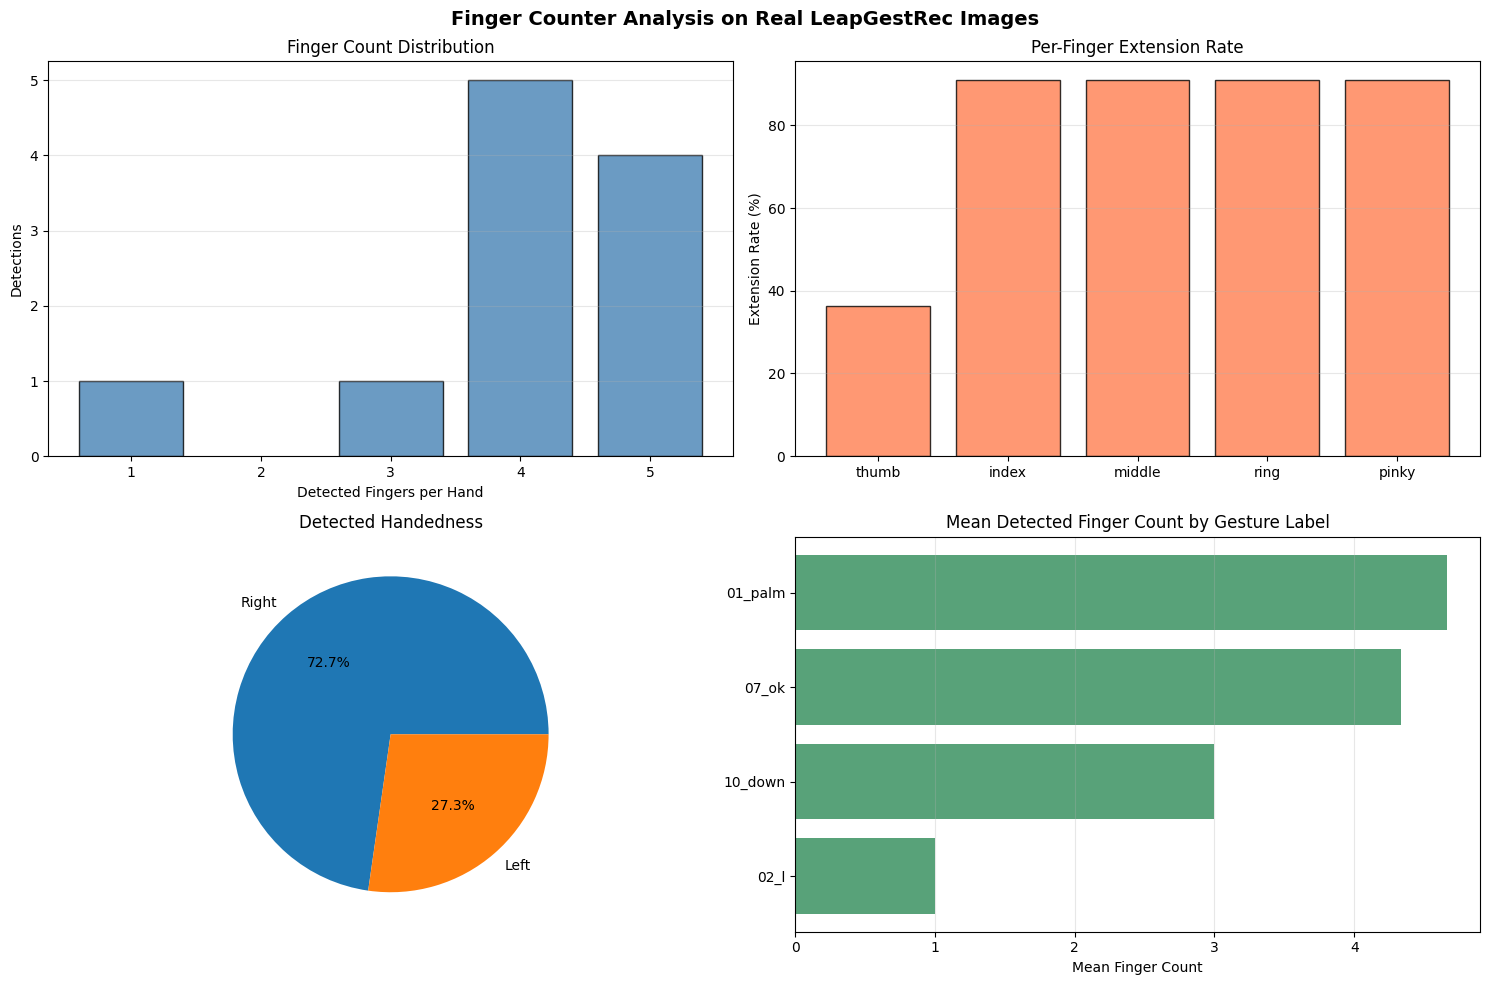

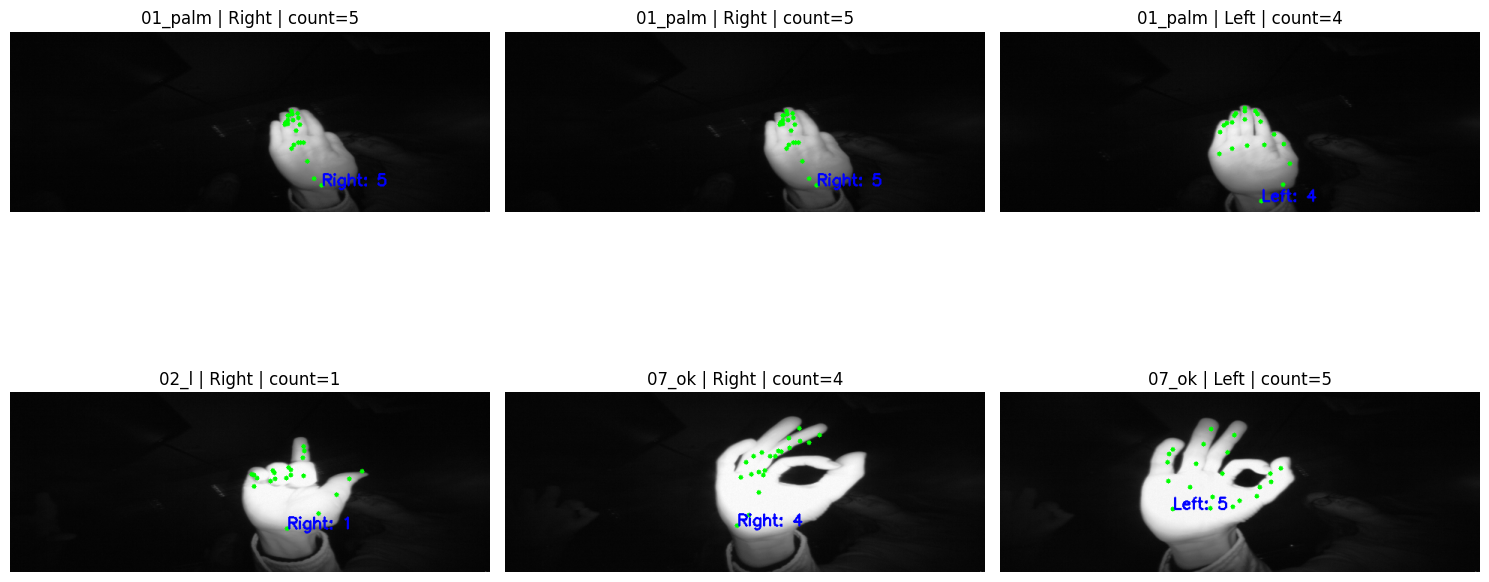

✓ Analysis plot saved to C:\Users\ahmad\finger_counter_project\outputs\finger_counter_analysis.png
✓ Preview grid saved to C:\Users\ahmad\finger_counter_project\outputs\finger_counter_previews.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Finger Counter Analysis on Real LeapGestRec Images', fontsize=14, fontweight='bold')

finger_distribution = results_df['finger_count'].value_counts().sort_index()
axes[0, 0].bar(finger_distribution.index, finger_distribution.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Finger Count Distribution')
axes[0, 0].set_xlabel('Detected Fingers per Hand')
axes[0, 0].set_ylabel('Detections')
axes[0, 0].grid(alpha=0.3, axis='y')

finger_names = ['thumb', 'index', 'middle', 'ring', 'pinky']
finger_rates = [results_df[finger_name].mean() * 100 for finger_name in finger_names]
axes[0, 1].bar(finger_names, finger_rates, color='coral', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Per-Finger Extension Rate')
axes[0, 1].set_ylabel('Extension Rate (%)')
axes[0, 1].grid(alpha=0.3, axis='y')

handedness_counts = results_df['handedness'].value_counts()
axes[1, 0].pie(handedness_counts.values, labels=handedness_counts.index, autopct='%1.1f%%')
axes[1, 0].set_title('Detected Handedness')

label_plot = label_summary.head(8).sort_values('mean')
axes[1, 1].barh(label_plot.index.astype(str), label_plot['mean'], color='seagreen', alpha=0.8)
axes[1, 1].set_title('Mean Detected Finger Count by Gesture Label')
axes[1, 1].set_xlabel('Mean Finger Count')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
analysis_plot_path = OUTPUT_DIR / 'finger_counter_analysis.png'
plt.savefig(analysis_plot_path, dpi=120, bbox_inches='tight')
plt.show()

preview_plot_path = OUTPUT_DIR / 'finger_counter_previews.png'
if preview_records:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for axis, preview_record in zip(axes, preview_records):
        axis.imshow(preview_record['image_rgb'])
        axis.set_title(preview_record['caption'])
        axis.axis('off')
    for axis in axes[len(preview_records):]:
        axis.axis('off')
    plt.tight_layout()
    plt.savefig(preview_plot_path, dpi=120, bbox_inches='tight')
    plt.show()
else:
    preview_plot_path = None

print(f'✓ Analysis plot saved to {analysis_plot_path}')
if preview_plot_path:
    print(f'✓ Preview grid saved to {preview_plot_path}')

## Save Results

In [11]:
results_csv_path = OUTPUT_DIR / 'finger_counter_results.csv'
results_df.to_csv(results_csv_path, index=False)

metrics = {
    'project': 'Project 5 - Finger Counter',
    'model': 'MediaPipe Hand Landmarker',
    'task_family': 'hand landmarks',
    'dataset': {
        'name': 'LeapGestRec',
        'source': 'https://www.kaggle.com/datasets/gti-upm/leapgestrecog',
        'root': str(DATASET_DIR),
        'participants_found': len(participant_ids),
        'labels_found': int(len(label_counts)),
        'images_found': int(len(image_paths)),
        'official_split': 'none provided by source'
    },
    'evaluation': {
        'sampled_images': int(len(sample_paths)),
        'images_with_hand_detection': int(images_with_hands),
        'detection_coverage_percent': round(float(detection_rate), 4),
        'hand_detections': int(len(results_df)),
        'avg_fingers_per_hand': round(float(results_df['finger_count'].mean()), 4),
        'finger_count_distribution': {str(key): int(value) for key, value in results_df['finger_count'].value_counts().sort_index().items()},
        'handedness_distribution': {str(key): int(value) for key, value in results_df['handedness'].value_counts(dropna=False).items()},
        'per_finger_extension_rate_percent': {finger_name: round(float(results_df[finger_name].mean() * 100), 4) for finger_name in ['thumb', 'index', 'middle', 'ring', 'pinky']}
    },
    'qualitative_note': 'This is an honest landmark-based audit on real downloaded gesture images, not a trained sign classifier benchmark.'
}

metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

manifest = {
    'project': 'Project 5 - Finger Counter',
    'preferred_stack': 'MediaPipe Hand Landmarker',
    'artifacts': {
        'metrics_json': str(metrics_path),
        'results_csv': str(results_csv_path),
        'analysis_plot': str(analysis_plot_path),
        'preview_plot': str(preview_plot_path) if preview_plot_path else None
    }
}

manifest_path = OUTPUT_DIR / 'project_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f'✓ Results table saved to {results_csv_path}')
print(f'✓ Metrics saved to {metrics_path}')
print(f'✓ Manifest saved to {manifest_path}')

✓ Results table saved to C:\Users\ahmad\finger_counter_project\outputs\finger_counter_results.csv
✓ Metrics saved to C:\Users\ahmad\finger_counter_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\finger_counter_project\outputs\project_manifest.json


## Limitations and Next Steps

**What this notebook does honestly:**
- downloads the real Kaggle dataset in code
- verifies discovered labels and the absence of an official split
- runs real MediaPipe hand landmark inference
- summarizes real finger-count outputs and saves real artifacts

**What it does not claim:**
- it does not pretend the dataset labels are direct finger-count ground truth
- it does not report a fabricated classification accuracy
- it does not benchmark sequence tracking on video because this dataset is image-based

**Natural next upgrades:**
- add a gesture-to-count label mapping only after auditing the dataset label semantics carefully
- add temporal smoothing on a real video dataset for live tracking evaluation
- compare MediaPipe landmarks with a learned gesture classifier for sign-specific tasks